In [36]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

spark = SparkSession.builder \
    .appName("profiling") \
    .config("spark.sql.ansi.enabled", "false") \
    .config("spark.driver.memory", "16g") \
    .getOrCreate()

df = spark.read.parquet("../data/cleaned/4c_eea_co2_emissions_from_passenger_cars-001.parquet")

Aggregate df to obtain registration counts, convert the Spark df to a Pandas df. Then, convert the TIME_PERIOD column to datetime format.

In [37]:
df = (
    df
    .filter(F.col("Motor energy") != "Alternative/Other")
    .groupBy("TIME_PERIOD", "Motor energy")
    .agg(F.sum("registrations").alias("registrations"))
)

pdf = df.toPandas()

pdf["TIME_PERIOD"] = pd.to_datetime(
    pdf["TIME_PERIOD"].astype(str),
    format="%Y"
)

pdf.head()

,TIME_PERIOD,Motor energy,registrations
0,2023-01-01,Diesel hybrid,29864
1,2020-01-01,Diesel (excluding hybrids),2977545
2,2021-01-01,Petrol hybrid,805966
3,2021-01-01,Petrol (excluding hybrids),5410452
4,2018-01-01,Diesel (excluding hybrids),4738593


Forecast total market volume until 2028 (5 years).

In [38]:
future_dates = pd.date_range(
    "2024",
    "2028",
    freq="YS"
)

total_series = (
    pdf.groupby("TIME_PERIOD")["registrations"]
    .sum()
    .asfreq("YS")
)

total_forecast = (
    ExponentialSmoothing(
        total_series,
        trend="add"
    )
    .fit()
    .forecast(len(future_dates))
)

display(total_forecast)

2024-01-01    9.747271e+06
2025-01-01    9.563920e+06
2026-01-01    9.380568e+06
2027-01-01    9.197217e+06
2028-01-01    9.013865e+06
Freq: YS-JAN, dtype: float64

Compute market shares for each motor energy category for the dataset years.

In [39]:
share_df = pdf.copy()

share_df["market_volume"] = (
    share_df.groupby("TIME_PERIOD")["registrations"]
    .transform("sum")
)

share_df["share"] = (
    share_df["registrations"] /
    share_df["market_volume"]
)

share_df.head()

,TIME_PERIOD,Motor energy,registrations,market_volume,share
0,2023-01-01,Diesel hybrid,29864,10103878,0.002956
1,2020-01-01,Diesel (excluding hybrids),2977545,9658230,0.308291
2,2021-01-01,Petrol hybrid,805966,9360404,0.086104
3,2021-01-01,Petrol (excluding hybrids),5410452,9360404,0.578015
4,2018-01-01,Diesel (excluding hybrids),4738593,12476802,0.379792


Compute market share for each motor energy category for forecasted years.

In [40]:
share_forecasts = []

for energy, data in share_df.groupby("Motor energy"):

    series = (
        data.set_index("TIME_PERIOD")["share"]
        .sort_index()
        .asfreq("YS")
    )

    forecast = (
        ExponentialSmoothing(
            series,
            trend="mul"
        )
        .fit()
        .forecast(len(future_dates))
    )

    share_forecasts.extend(
        {
            "TIME_PERIOD": year,
            "Motor energy": energy,
            "share": value
        }
        for year, value in zip(future_dates, forecast)
    )


share_forecast_df = pd.DataFrame(share_forecasts)

share_forecast_df["share"] = (
    share_forecast_df
    .groupby("TIME_PERIOD")["share"]
    .transform(lambda x: x / x.sum())
)

share_forecast_df.head()

c:\Users\mac8\Documents\UniTN LM Informatica\Corsi\Data Visualization Lab\dataviz-project\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\mac8\Documents\UniTN LM Informatica\Corsi\Data Visualization Lab\dataviz-project\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,TIME_PERIOD,Motor energy,share
0,2024-01-01,Diesel (excluding hybrids),0.149907
1,2025-01-01,Diesel (excluding hybrids),0.125417
2,2026-01-01,Diesel (excluding hybrids),0.104123
3,2027-01-01,Diesel (excluding hybrids),0.085806
4,2028-01-01,Diesel (excluding hybrids),0.070210


Convert market share values into registration counts.

In [41]:
forecast_df = share_forecast_df.copy()

forecast_df["registrations"] = (
    forecast_df["share"] *
    forecast_df["TIME_PERIOD"].map(total_forecast)
).round().astype(int)

forecast_df["type"] = "forecast"


historical_df = pdf.copy()
historical_df["type"] = "historical"


combined_df = pd.concat(
    [
        historical_df,
        forecast_df
    ],
    ignore_index=True
)

combined_df.head()

,TIME_PERIOD,Motor energy,registrations,type,share
0,2023-01-01,Diesel hybrid,29864,historical,NaN
1,2020-01-01,Diesel (excluding hybrids),2977545,historical,NaN
2,2021-01-01,Petrol hybrid,805966,historical,NaN
3,2021-01-01,Petrol (excluding hybrids),5410452,historical,NaN
4,2018-01-01,Diesel (excluding hybrids),4738593,historical,NaN


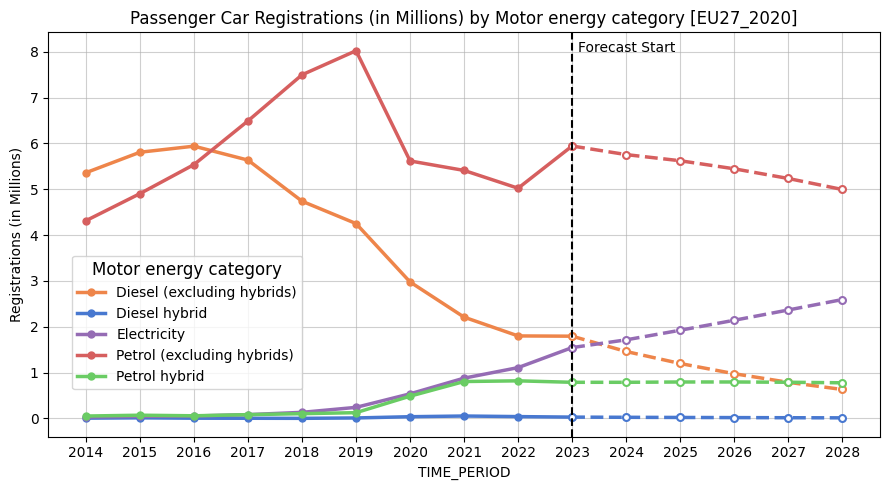

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plot_df = combined_df.copy()

# Convert the TIME_PERIOD column to "YEAR"
plot_df["TIME_PERIOD"] = plot_df["TIME_PERIOD"].apply(
    lambda x: x.year if hasattr(x, "year") else x
)

fig, ax = plt.subplots(figsize=(9, 5))
color_map = dict(zip(plot_df["Motor energy"].unique(), sns.color_palette("muted")))

for energy, data in plot_df.groupby("Motor energy"):
    color = color_map[energy]
    
    historical = data[data["type"] == "historical"].sort_values("TIME_PERIOD")
    forecast = data[data["type"] == "forecast"].sort_values("TIME_PERIOD")

    # Historical data
    ax.plot(
        historical["TIME_PERIOD"],
        historical["registrations"] / 1_000_000,  # To Millions
        marker="o",
        markersize=5,
        linewidth=2.5,
        color=color,
        label=energy
    )

    # Forecast data
    if not forecast.empty:
        forecast_first = pd.concat([historical.tail(1), forecast])
        ax.plot(
            forecast_first["TIME_PERIOD"],
            forecast_first["registrations"] / 1_000_000,  # To Millions
            linestyle="--",
            marker="o",
            markersize=5,
            markerfacecolor="white",
            markeredgewidth=1.5,
            linewidth=2.5,
            color=color
        )

# Divisor line for forecast start
ax.axvline(2023, color="black", linestyle="--", linewidth=1.5)
ax.text(2023.1, ax.get_ylim()[1] * 0.95, "Forecast Start", color="black", fontsize=10)

ax.set_xticks(range(2014, 2029))
ax.grid(True, linestyle="-", alpha=0.6)
ax.legend(title="Motor energy category", loc="lower left", bbox_to_anchor=(0.02, 0.10),fontsize=10, title_fontsize=12)

plt.xlabel("TIME_PERIOD")
plt.ylabel("Registrations (in Millions)")
plt.title("Passenger Car Registrations (in Millions) by Motor energy category [EU27_2020]")

plt.tight_layout()
plt.savefig("img/time_series_forecast.png", dpi=300)
plt.show()
